<a href="https://colab.research.google.com/github/hangkimdiep-boop/RL_E1405_Submited_2026/blob/main/MICROGRID_ENERGY_OPTIMIZATION_2%24_PPO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MICROGRID ENERGY OPTIMIZATION - PPO (Proximal Policy Optimization)**

Author: Hang Diep Kim

Date: February 2026

**1️⃣ Install Dependencies & Imports**

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import json, os, time
from torch.distributions import Categorical
from collections import deque
from typing import Dict, List, Tuple, Optional


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")


🖥️ Using device: cuda


**2️⃣ PPO Configuration**



*   PPO HYPERPARAMETERS



In [2]:
CONFIG = {
    # SETUP ENVIRONMENT
    "battery_capacity": 100,
    "battery_efficiency": 0.95,
    "max_charge_rate": 20,
    "max_discharge_rate": 20,
    "max_solar": 50,
    "max_wind": 30,
    "base_demand": 40,
    "demand_std": 10,
    "grid_price_max": 0.25,
    "grid_price_min": 0.05,
    "hours_per_episode": 24,

    # PPO SPECIFIC
    "state_dim": 8, # State Space (8D): battery, solar, wind, price, hour_sin, hour_cos, prev_action, demand
    "action_dim": 5,# Action Space (5): discharge, charge_renewable, buy_grid, renew + discharge, renew + grid

    # NETWORK ARCHITECTURE
    "hidden_dims": [128, 128],

    # LEARNING RATE
    "lr_actor": 3e-4,
    "lr_critic": 1e-3,

    # PPO PARAMETERS
    "gamma": 0.995,               # Discount factor
    "gae_lambda": 0.95,          # GAE lambda
    "clip_epsilon": 0.2,         # PPO clipping range
    "ppo_epochs": 12,            # Update epochs per rollout
    "mini_batch_size": 64,       # Mini-batch size
    "entropy_coeff": 0.1,       # Entropy bonus
    "value_loss_coeff": 0.5,     # Value loss weight
    "max_grad_norm": 0.5,        # Gradient clipping

    # TRAINING
    "num_episodes": 1000,
    "max_steps_per_episode": 24, # 1 episode = 1 day (24h, step 1h)
    "rollout_steps": 96,         # Steps before update (4 episodes)
    "log_freq": 10,

    # RANDOM SEED
    "seed": 42,

    # REWARD
    "reward_renewable": 1.0,
    "reward_grid_penalty": -4.0,
    "reward_unmet_penalty": -5.0,
    "reward_battery_wear": -0.1,
    "reward_peak_bonus": 1.2,

    # TERMINATION
    "battery_critical_low": 0.05,
    "battery_critical_high": 1.0,
    "max_unmet_ratio": 0.20,
}

print("✅ PPO Config loaded!")
print(f"   LR Actor: {CONFIG['lr_actor']}, LR Critic: {CONFIG['lr_critic']}")
print(f"   Clip ε: {CONFIG['clip_epsilon']}, PPO Epochs: {CONFIG['ppo_epochs']}")
print(f"   GAE λ: {CONFIG['gae_lambda']}, Entropy: {CONFIG['entropy_coeff']}")

✅ PPO Config loaded!
   LR Actor: 0.0003, LR Critic: 0.001
   Clip ε: 0.2, PPO Epochs: 12
   GAE λ: 0.95, Entropy: 0.1


**3️⃣ Microgrid Environment**

In [3]:
class MicrogridEnv:
    def __init__(self, config: Dict):
        self.config = config
        self.battery_capacity = config["battery_capacity"]
        self.battery_efficiency = config["battery_efficiency"]
        self.max_charge = config["max_charge_rate"]
        self.max_discharge = config["max_discharge_rate"]
        self.max_solar = config["max_solar"]
        self.max_wind = config["max_wind"]
        self.base_demand = config["base_demand"]
        self.demand_std = config["demand_std"]
        self.grid_price_min = config["grid_price_min"]
        self.grid_price_max = config["grid_price_max"]
        self.hours_per_episode = config["hours_per_episode"]
        self.r_renewable = config["reward_renewable"]
        self.r_grid = config["reward_grid_penalty"]
        self.r_unmet = config["reward_unmet_penalty"]
        self.r_wear = config["reward_battery_wear"]
        self.r_bonus = config["reward_peak_bonus"]
        self.battery_critical_low = config.get("battery_critical_low", 0.05)
        self.battery_critical_high = config.get("battery_critical_high", 1.0)
        self.max_unmet_ratio = config.get("max_unmet_ratio", 0.20)
        self.reset()

    def reset(self, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.battery_level = self.battery_capacity * 0.5
        self.current_hour = 0
        self.prev_action = 0
        self.total_demand = 0.0
        self.total_grid_cost = 0.0
        self.total_renewable_used = 0.0
        self.total_unmet = 0.0
        self.episode_history = []
        return self._get_obs()

    def _get_obs(self):
        d = self._get_demand(self.current_hour)
        p = self._get_price(self.current_hour)
        s = self._get_solar(self.current_hour)
        w = self._get_wind(self.current_hour)

        obs = np.array([
            self.battery_level / self.battery_capacity,
            d / (self.base_demand * 2),
            s / self.max_solar,
            w / self.max_wind,
            (p - self.grid_price_min) / (self.grid_price_max - self.grid_price_min),
            (np.sin(2 * np.pi * self.current_hour / 24) + 1) / 2,
            (np.cos(2 * np.pi * self.current_hour / 24) + 1) / 2,
            self.prev_action / 4.0,
        ], dtype=np.float32)
        return np.clip(obs, 0.0, 1.0)

    def _get_demand(self, hour):
        mp = np.exp(-((hour - 8) ** 2) / 8)
        ep = np.exp(-((hour - 19) ** 2) / 8)
        base = self.base_demand * (0.5 + 0.3 * mp + 0.4 * ep)
        return max(0, base + np.random.normal(0, self.demand_std * 0.3))

    def _get_solar(self, hour):
        if 6 <= hour <= 18:
            base = self.max_solar * np.sin(np.pi * (hour - 6) / 12)
            return max(0, base * np.random.uniform(0.8, 1.2))
        return 0.0

    def _get_wind(self, hour):
        base = self.max_wind * 0.5
        var = self.max_wind * 0.5 * np.sin(np.pi * hour / 12)
        return max(0, (base + var) * np.random.uniform(0.5, 1.5))

    def _get_price(self, hour):
        if 7 <= hour <= 9 or 18 <= hour <= 21:
            base = self.grid_price_max
        elif 22 <= hour or hour <= 6:
            base = self.grid_price_min
        else:
            base = (self.grid_price_min + self.grid_price_max) / 2
        return base * np.random.uniform(0.9, 1.1)

    def step(self, action):
        demand = self._get_demand(self.current_hour)
        solar = self._get_solar(self.current_hour)
        wind = self._get_wind(self.current_hour)
        price = self._get_price(self.current_hour)
        renewable = solar + wind

        renewable_used = grid_purchased = battery_charge = battery_discharge = unmet_demand = 0.0
        is_peak = 18 <= self.current_hour <= 21
        is_low_price = price <= self.grid_price_min * 1.2

        if action == 0:  # Discharge
            discharge = min(self.battery_level, self.max_discharge, demand)
            battery_discharge = discharge
            self.battery_level -= discharge
            remaining = demand - discharge * self.battery_efficiency
            if remaining > 0: grid_purchased = remaining
        elif action == 1:  # Charge from renewable
            supply = min(renewable, demand)
            renewable_used = supply
            remaining = demand - renewable_used
            if remaining > 0:
                grid_purchased = remaining
                unmet_demand = 0.0
            excess_renewable = renewable - renewable_used
            if excess_renewable > 0:
                charge = min(excess_renewable, self.max_charge, self.battery_capacity - self.battery_level)
                battery_charge = charge
                self.battery_level += charge * self.battery_efficiency
        elif action == 2:  # Buy from grid
            grid_purchased = demand
        elif action == 3:  # Renewable + Discharge
            renewable_used = min(renewable, demand)
            remaining = demand - renewable_used
            if remaining > 0:
                discharge = min(self.battery_level, self.max_discharge, remaining)
                battery_discharge = discharge
                self.battery_level -= discharge
                remaining -= discharge * self.battery_efficiency
            if remaining > 0: unmet_demand = remaining
        elif action == 4:  # Renewable + Grid
            renewable_used = min(renewable, demand)
            remaining = demand - renewable_used
            if remaining > 0: grid_purchased = remaining

        # Reward
        norm_price = (price - self.grid_price_min) / (self.grid_price_max - self.grid_price_min)
        is_peak = 18 <= self.current_hour <= 21
        reward = (
            self.r_renewable * (renewable_used / self.base_demand)
            + self.r_grid * (grid_purchased / self.base_demand) * norm_price
            + self.r_unmet * (unmet_demand / self.base_demand)
            + self.r_wear * ((battery_charge + battery_discharge) / self.max_charge)
        )
        if battery_charge > 0:
            reward += 1 * (battery_charge / self.max_charge)

        if action == 1 and battery_charge > 0: #Charge from renewable
            reward += 0.5  # Bonus

        if action == 0 and is_peak and battery_discharge > 0: #Discharge
            reward += 0.5  # Bonus

        if action == 2 and is_low_price: #Buy from grid
            reward += 0.2  # Bonus

        if is_peak and grid_purchased == 0:
            reward += self.r_bonus # Corrected line: Removed [8]
        self.total_demand += demand
        self.total_renewable_used += renewable_used
        self.total_grid_cost += grid_purchased * price
        self.total_unmet += unmet_demand
        self.episode_history.append({
            "hour": self.current_hour, "demand": demand, "solar": solar,
            "wind": wind, "price": price, "action": action,
            "renewable_used": renewable_used, "grid_purchased": grid_purchased,
            "battery_level": self.battery_level, "reward": reward,
        })

        self.current_hour += 1
        self.prev_action = action

        done = self.current_hour >= self.hours_per_episode
        bat_ratio = self.battery_level / self.battery_capacity
        if bat_ratio < self.battery_critical_low: done = True
        if self.total_demand > 0 and self.total_unmet / self.total_demand > self.max_unmet_ratio:
            done = True

        info = {
            "total_cost": self.total_grid_cost,
            "renewable_ratio": self.total_renewable_used / max(1, self.total_demand),
            "unmet_ratio": self.total_unmet / max(1, self.total_demand),
        }
        return self._get_obs(), reward, done, info

print("✅ MicrogridEnv defined!")

✅ MicrogridEnv defined!


**4️⃣ Actor-Critic Network**

In [4]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dims: List[int]):
        super().__init__()

        # Sharing feature extractor
        shared_layers = []
        prev_dim = state_dim
        for h in hidden_dims:
            shared_layers.extend([nn.Linear(prev_dim, h), nn.Tanh()])
            prev_dim = h
        self.shared = nn.Sequential(*shared_layers)

        # Actor head of policy
        self.actor = nn.Sequential(
            nn.Linear(prev_dim, action_dim),
            nn.Softmax(dim=-1)
        )

        # Critic head of value
        self.critic = nn.Linear(prev_dim, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.shared(x)
        return self.actor(features), self.critic(features)

    def get_action(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(next(self.parameters()).device)
        probs, value = self.forward(state_t)
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action).item(), value.item()

    def evaluate(self, states, actions):
        probs, values = self.forward(states)
        dist = Categorical(probs)
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy()
        return log_probs, values.squeeze(-1), entropy

print("✅ ActorCritic network defined!")

✅ ActorCritic network defined!


**5️⃣ PPO Agent**

In [5]:
class RolloutBuffer:
    def __init__(self):
        self.clear()

    def clear(self):
        self.states = []
        self.actions = []
        self.rewards = []
        self.values = []
        self.log_probs = []
        self.dones = []

    def add(self, state, action, log_prob, reward, value, done):
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.values.append(value)
        self.log_probs.append(log_prob)
        self.dones.append(done)

    def __len__(self):
        return len(self.states)

class PPOAgent:
    def __init__(self, config: Dict, device: torch.device):
        self.device = device
        self.config = config
        self.gamma = config["gamma"]
        self.gae_lambda = config["gae_lambda"]
        self.clip_epsilon = config["clip_epsilon"]
        self.ppo_epochs = config["ppo_epochs"]
        self.mini_batch_size = config["mini_batch_size"]
        self.entropy_coeff = config["entropy_coeff"]
        self.value_loss_coeff = config["value_loss_coeff"]
        self.max_grad_norm = config["max_grad_norm"]

        # Actor - Critic
        self.network = ActorCritic(
            config["state_dim"], config["action_dim"], config["hidden_dims"]
        ).to(device)

        # Separate learning rates for Actor & Critic
        self.optimizer = optim.Adam([
            {"params": self.network.shared.parameters(), "lr": config["lr_actor"]},
            {"params": self.network.actor.parameters(), "lr": config["lr_actor"]},
            {"params": self.network.critic.parameters(), "lr": config["lr_critic"]},
        ])

        self.buffer = RolloutBuffer()
        self.training_step = 0

    def select_action(self, state, eval_mode=False):
        if eval_mode:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                probs, _ = self.network(state_t)
                return probs.argmax(dim=-1).item()
        action, log_prob, value = self.network.get_action(state)
        return action, log_prob, value

    def store(self, state, action, log_prob, reward, value, done):
        self.buffer.add(state, action, log_prob, reward, value, done)

    def compute_gae(self, next_value):
        rewards = self.buffer.rewards
        values = self.buffer.values + [next_value]
        dones = self.buffer.dones
        advantages = []
        gae = 0
        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t + 1] * (1 - dones[t]) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - dones[t]) * gae
            advantages.insert(0, gae)

        advantages = torch.FloatTensor(advantages).to(self.device)
        returns = advantages + torch.FloatTensor(self.buffer.values).to(self.device)
        return advantages, returns

    def update(self, next_value):
        advantages, returns = self.compute_gae(next_value)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Tensors
        states = torch.FloatTensor(np.array(self.buffer.states)).to(self.device)
        actions = torch.LongTensor(self.buffer.actions).to(self.device)
        old_log_probs = torch.FloatTensor(self.buffer.log_probs).to(self.device)

        total_loss_val = 0
        n_updates = 0

        for _ in range(self.ppo_epochs):
            # Mini iteration
            indices = np.random.permutation(len(self.buffer))
            for start in range(0, len(self.buffer), self.mini_batch_size):
                end = start + self.mini_batch_size
                idx = indices[start:end]

                # Evaluate current policy
                new_log_probs, new_values, entropy = self.network.evaluate(
                    states[idx], actions[idx]
                )

                # PPO clipped objective
                ratio = torch.exp(new_log_probs - old_log_probs[idx])
                surr1 = ratio * advantages[idx]
                surr2 = torch.clamp(ratio, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * advantages[idx]
                policy_loss = -torch.min(surr1, surr2).mean()

                # Value loss
                value_loss = nn.MSELoss()(new_values, returns[idx])

                # Total loss
                loss = (
                    policy_loss
                    + self.value_loss_coeff * value_loss
                    - self.entropy_coeff * entropy.mean()
                )

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
                self.optimizer.step()

                total_loss_val += loss.item()
                n_updates += 1

        self.buffer.clear()
        self.training_step += 1
        return total_loss_val / max(1, n_updates)

print("✅ PPO Agent is defined!")

✅ PPO Agent is defined!


**6️⃣ Training Loop**

In [6]:
# Setup seed
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

env = MicrogridEnv(CONFIG)
agent = PPOAgent(CONFIG, device)

# Training metrics
cost_history = []
loss_history = []
rewards_history = []
renewable_history = []

NUM_EPISODES = CONFIG["num_episodes"]
print("=" * 60)
print(f"Training PPO Agent with {NUM_EPISODES} episodes")
print("=" * 60)

start_time = time.time()
steps_since_update = 0

for episode in range(1, NUM_EPISODES + 1):
    state = env.reset(seed=CONFIG["seed"] + episode)
    episode_reward = 0

    for step in range(CONFIG["max_steps_per_episode"]):
        action, log_prob, value = agent.select_action(state)
        next_state, reward, done, info = env.step(action)

        agent.store(state, action, log_prob, reward, value, float(done))
        episode_reward += reward
        steps_since_update += 1
        state = next_state

        # Updated
        if steps_since_update >= CONFIG["rollout_steps"]:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                _, next_value = agent.network(state_t)
                next_value = next_value.item()
            loss = agent.update(next_value)
            loss_history.append(loss)
            steps_since_update = 0

        if done:
            break

    rewards_history.append(episode_reward)
    renewable_history.append(info["renewable_ratio"])
    cost_history.append(info["total_cost"])

    if episode % CONFIG["log_freq"] == 0:
        avg_r = np.mean(rewards_history[-CONFIG["log_freq"]:])
        avg_ren = np.mean(renewable_history[-CONFIG["log_freq"]:])
        elapsed = time.time() - start_time
        print(f"Ep {episode:4d}/{NUM_EPISODES} | "
              f"Reward: {avg_r:7.2f} | "
              f"Renewable: {avg_ren:.1%} | "
              f"Cost: ${info['total_cost']:.2f} | "
              f"Time: {elapsed:.0f}s")

# Handling remaining data
if len(agent.buffer) > 0:
    with torch.no_grad():
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        _, next_value = agent.network(state_t)
        next_value = next_value.item()
    agent.update(next_value)

total_time = time.time() - start_time
print(f"\n✅ Training is completed in {total_time:.1f}s")

Training PPO Agent with 1000 episodes
Ep   10/1000 | Reward:   -2.01 | Renewable: 28.1% | Cost: $45.62 | Time: 1s
Ep   20/1000 | Reward:   -2.22 | Renewable: 44.7% | Cost: $22.16 | Time: 2s
Ep   30/1000 | Reward:    2.34 | Renewable: 48.6% | Cost: $11.99 | Time: 2s
Ep   40/1000 | Reward:    0.68 | Renewable: 45.8% | Cost: $10.31 | Time: 3s
Ep   50/1000 | Reward:    2.83 | Renewable: 49.4% | Cost: $5.52 | Time: 3s
Ep   60/1000 | Reward:    3.45 | Renewable: 54.5% | Cost: $16.56 | Time: 3s
Ep   70/1000 | Reward:    4.29 | Renewable: 50.1% | Cost: $0.17 | Time: 4s
Ep   80/1000 | Reward:    5.20 | Renewable: 54.5% | Cost: $39.48 | Time: 5s
Ep   90/1000 | Reward:    7.87 | Renewable: 59.0% | Cost: $5.61 | Time: 5s
Ep  100/1000 | Reward:    7.10 | Renewable: 60.9% | Cost: $5.74 | Time: 6s
Ep  110/1000 | Reward:   10.92 | Renewable: 63.9% | Cost: $8.16 | Time: 6s
Ep  120/1000 | Reward:   11.08 | Renewable: 64.1% | Cost: $11.59 | Time: 7s
Ep  130/1000 | Reward:   11.94 | Renewable: 66.7% | Cos

**7️⃣ Evaluation & Comparison**

In [7]:
os.makedirs("evaluation_results", exist_ok=True)

print("\n" + "=" * 60)
print("7️⃣ Evaluation & Comparison: PPO Agent vs Random Baseline")
print("=" * 60)

def evaluate_agent(agent, config, use_random=False, num_eval=20):
    """Evaluate agent over multiple episodes."""
    eval_env = MicrogridEnv(config)
    all_rewards, all_costs, all_renewable, all_unmet = [], [], [], []

    for i in range(num_eval):
        state = eval_env.reset(seed=config["seed"] + 10000 + i)
        ep_reward = 0
        for _ in range(config["max_steps_per_episode"]):
            if use_random:
                action = random.randint(0, config["action_dim"] - 1)
            else:
                action = agent.select_action(state, eval_mode=True)
            state, reward, done, info = eval_env.step(action)
            ep_reward += reward
            if done:
                break
        all_rewards.append(ep_reward)
        all_costs.append(info["total_cost"])
        all_renewable.append(info["renewable_ratio"])
        all_unmet.append(info["unmet_ratio"])

    return {
        "rewards": np.mean(all_rewards),
        "costs": np.mean(all_costs),
        "renewable": np.mean(all_renewable),
        "unmet": np.mean(all_unmet),
    }

ppo_results = evaluate_agent(agent, CONFIG, use_random=False)
random_results = evaluate_agent(agent, CONFIG, use_random=True)

# Print comparison
print(f"\n{'Metric':<25} {'PPO Agent':>12} {'Random':>12} {'Improvement':>12}")
print("-" * 65)
for key in ["rewards", "costs", "renewable", "unmet"]:
    ppo_v = ppo_results[key]
    rand_v = random_results[key]
    if key == "costs":
        imp = (rand_v - ppo_v) / max(abs(rand_v), 1e-8) * 100
        print(f"{key:<25} ${ppo_v:>10.2f} ${rand_v:>10.2f} {imp:>10.1f}%")
    else:
        imp = (ppo_v - rand_v) / max(abs(rand_v), 1e-8) * 100
        print(f"{key:<25} {ppo_v:>11.3f} {rand_v:>11.3f} {imp:>10.1f}%")


7️⃣ Evaluation & Comparison: PPO Agent vs Random Baseline

Metric                       PPO Agent       Random  Improvement
-----------------------------------------------------------------
rewards                        17.229       0.327     5169.9%
costs                     $      2.08 $     17.37       88.0%
renewable                       0.693       0.395       75.7%
unmet                           0.088       0.007     1081.3%


**8️⃣ Visualization**


📁 Saved: evaluation_results/ppo_training_results.png


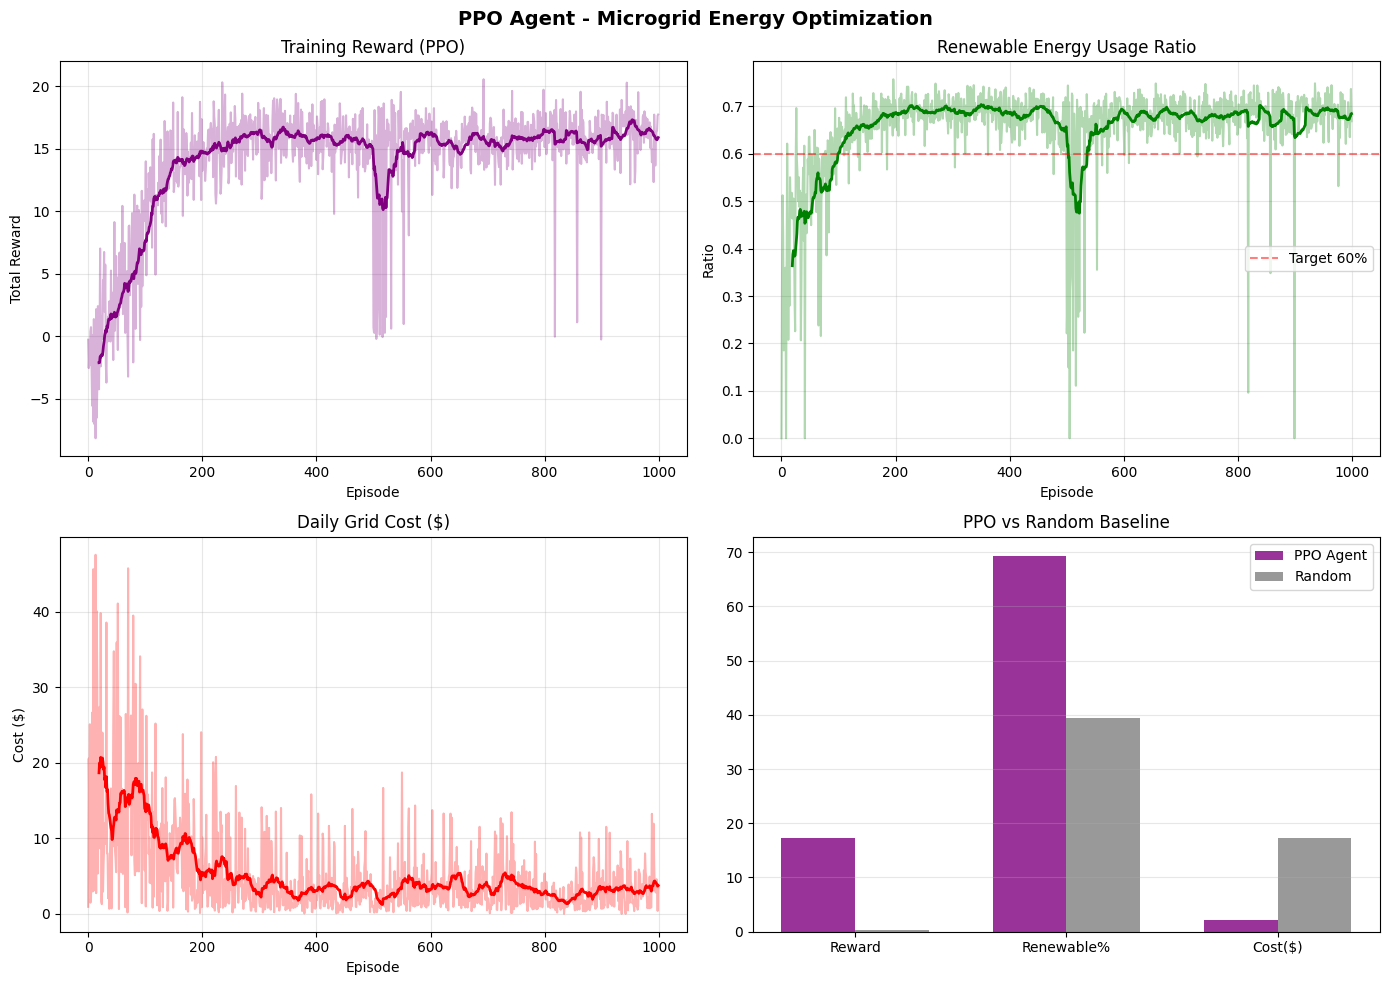

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("PPO Agent - Microgrid Energy Optimization", fontsize=14, fontweight="bold")

# Training reward
ax = axes[0, 0]
ax.plot(rewards_history, alpha=0.3, color="purple")
w = 20
if len(rewards_history) >= w:
    smoothed = np.convolve(rewards_history, np.ones(w)/w, mode="valid")
    ax.plot(range(w-1, len(rewards_history)), smoothed, color="purple", linewidth=2)
ax.set_title("Training Reward (PPO)")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.grid(True, alpha=0.3)

# Renewable ratio
ax = axes[0, 1]
ax.plot(renewable_history, alpha=0.3, color="green")
if len(renewable_history) >= w:
    smoothed = np.convolve(renewable_history, np.ones(w)/w, mode="valid")
    ax.plot(range(w-1, len(renewable_history)), smoothed, color="green", linewidth=2)
ax.set_title("Renewable Energy Usage Ratio")
ax.set_xlabel("Episode")
ax.set_ylabel("Ratio")
ax.axhline(y=0.6, color="r", linestyle="--", alpha=0.5, label="Target 60%")
ax.legend()
ax.grid(True, alpha=0.3)

# Grid cost
ax = axes[1, 0]
ax.plot(cost_history, alpha=0.3, color="red")
if len(cost_history) >= w:
    smoothed = np.convolve(cost_history, np.ones(w)/w, mode="valid")
    ax.plot(range(w-1, len(cost_history)), smoothed, color="red", linewidth=2)
ax.set_title("Daily Grid Cost ($)")
ax.set_xlabel("Episode")
ax.set_ylabel("Cost ($)")
ax.grid(True, alpha=0.3)

# PPO vs random comparison
ax = axes[1, 1]
labels = ["Reward", "Renewable%", "Cost($)"]
ppo_vals = [ppo_results["rewards"], ppo_results["renewable"]*100, ppo_results["costs"]]
rand_vals = [random_results["rewards"], random_results["renewable"]*100, random_results["costs"]]
x = np.arange(len(labels))
bar_w = 0.35
ax.bar(x - bar_w/2, ppo_vals, bar_w, label="PPO Agent", color="purple", alpha=0.8)
ax.bar(x + bar_w/2, rand_vals, bar_w, label="Random", color="gray", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("PPO vs Random Baseline")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("evaluation_results/ppo_training_results.png", dpi=150, bbox_inches="tight")
print("\n📁 Saved: evaluation_results/ppo_training_results.png")
plt.show()

**9️⃣ 24-Hour Energy Dispatch Profile**

📁 Saved: evaluation_results/ppo_dispatch_profile.png


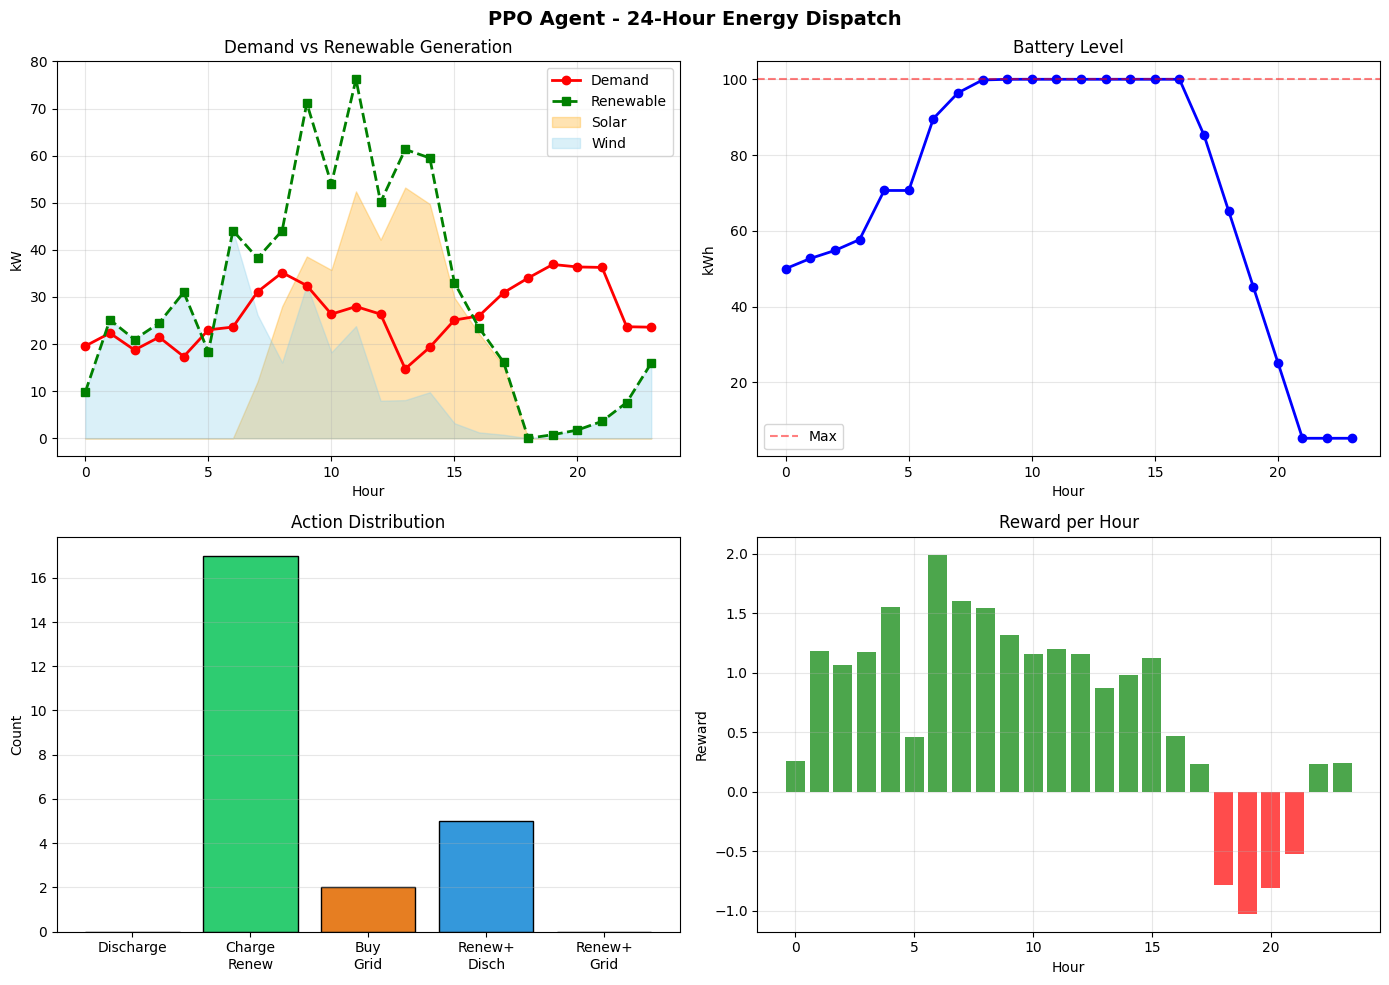


✅ PPO training and evaluation are completed!
Results saved in evaluation_results/
Algorithm: PPO (Proximal Policy Optimization)
Reference: Schulman et al., 2017


In [9]:
eval_env = MicrogridEnv(CONFIG)
state = eval_env.reset(seed=CONFIG["seed"])
for _ in range(24):
    action = agent.select_action(state, eval_mode=True)
    state, _, done, _ = eval_env.step(action)
    if done:
        break

history = eval_env.episode_history
hours = [h["hour"] for h in history]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("PPO Agent - 24-Hour Energy Dispatch", fontsize=14, fontweight="bold")

# Demand vs Renewable
ax = axes[0, 0]
ax.plot(hours, [h["demand"] for h in history], "r-o", label="Demand", linewidth=2)
ax.plot(hours, [h["solar"] + h["wind"] for h in history], "g--s", label="Renewable", linewidth=2)
ax.fill_between(hours, [h["solar"] for h in history], alpha=0.3, color="orange", label="Solar")
ax.fill_between(hours, [h["wind"] for h in history], alpha=0.3, color="skyblue", label="Wind")
ax.set_title("Demand vs Renewable Generation")
ax.set_xlabel("Hour")
ax.set_ylabel("kW")
ax.legend()
ax.grid(True, alpha=0.3)

# Battery Level
ax = axes[0, 1]
ax.plot(hours, [h["battery_level"] for h in history], "b-o", linewidth=2)
ax.axhline(y=CONFIG["battery_capacity"], color="r", linestyle="--", alpha=0.5, label="Max")
ax.set_title("Battery Level")
ax.set_xlabel("Hour")
ax.set_ylabel("kWh")
ax.legend()
ax.grid(True, alpha=0.3)

# Actions
ax = axes[1, 0]
action_names = ["Discharge", "Charge\nRenew", "Buy\nGrid", "Renew+\nDisch", "Renew+\nGrid"]
action_counts = [sum(1 for h in history if h["action"] == i) for i in range(5)]
colors = ["#e74c3c", "#2ecc71", "#e67e22", "#3498db", "#9b59b6"]
ax.bar(action_names, action_counts, color=colors, edgecolor="black")
ax.set_title("Action Distribution")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3, axis="y")

# Reward/hour
ax = axes[1, 1]
ax.bar(hours, [h["reward"] for h in history],
       color=["green" if h["reward"] > 0 else "red" for h in history], alpha=0.7)
ax.set_title("Reward per Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Reward")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_results/ppo_dispatch_profile.png", dpi=150, bbox_inches="tight")
print("📁 Saved: evaluation_results/ppo_dispatch_profile.png")
plt.show()

print("\n" + "=" * 60)
print("✅ PPO training and evaluation are completed!")
print("=" * 60)
print(f"Results saved in evaluation_results/")
print(f"Algorithm: PPO (Proximal Policy Optimization)")
print(f"Reference: Schulman et al., 2017")